In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB

In [459]:
df = pd.read_csv('./spambase/spambase.data', header=None)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4601, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [460]:
# Separate features (X) and labels (y)
X = df.iloc[:, :-1]   # First 57 columns 
y = df.iloc[:, -1]    # Last column

df.iloc[:, -1].value_counts()

57
0    2788
1    1813
Name: count, dtype: int64

In [461]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3450
Testing samples: 1151


In [462]:
# Function to calculate all metrics
def calculate_metrics(model, X_train, X_test, y_train, y_test):
    """
    Calculate training and testing metrics for a model.
    Returns: dictionary with all metrics
    """
    
    # Predictions on training set
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]
    
    # Predictions on testing set
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_error = 1 - train_accuracy
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    
    # Calculate testing metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_error = 1 - test_accuracy
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    return {
        'Train Error': round(train_error, 4),
        'Train Accuracy': round(train_accuracy, 4),
        'Train F1': round(train_f1, 4),
        'Train AUC': round(train_auc, 4),
        'Test Error': round(test_error, 4),
        'Test Accuracy': round(test_accuracy, 4),
        'Test F1': round(test_f1, 4),
        'Test AUC': round(test_auc, 4)}

In [463]:
# 1.1:
# Create decision tree with entropy splitting criteria (NO pruning)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train the model
dt_entropy.fit(X_train, y_train)

print("Tree depth:", dt_entropy.get_depth())
print("Number of leaves:", dt_entropy.get_n_leaves())

Tree depth: 26
Number of leaves: 185


In [464]:
# Calculate metrics for Information Gain tree
metrics_entropy = calculate_metrics(dt_entropy, X_train, X_test, y_train, y_test)

print("DECISION TREE WITH INFORMATION GAIN (ENTROPY):")
print("\nTraining Metrics:")
print(f" Error:    {metrics_entropy['Train Error']}")
print(f" Accuracy: {metrics_entropy['Train Accuracy']}")
print(f" F1 Score: {metrics_entropy['Train F1']}")
print(f" AUC:      {metrics_entropy['Train AUC']}")

print("\nTesting Metrics:")
print(f" Error:    {metrics_entropy['Test Error']}")
print(f" Accuracy: {metrics_entropy['Test Accuracy']}")
print(f" F1 Score: {metrics_entropy['Test F1']}")
print(f" AUC:      {metrics_entropy['Test AUC']}")

DECISION TREE WITH INFORMATION GAIN (ENTROPY):

Training Metrics:
 Error:    0.0006
 Accuracy: 0.9994
 F1 Score: 0.9993
 AUC:      1.0

Testing Metrics:
 Error:    0.0765
 Accuracy: 0.9235
 F1 Score: 0.906
 AUC:      0.9189



Observation: Training accuracy is very high (100%), Testing accuracy is lower, indicating overfitting.

In [465]:
# 1.2: Train decision tree with Gini Index

# Create decision tree with Gini splitting criteria 
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)

# Train the model
dt_gini.fit(X_train, y_train)

print("Tree depth:", dt_gini.get_depth())
print("Number of leaves:", dt_gini.get_n_leaves())


Tree depth: 29
Number of leaves: 233


In [466]:
# Calculate metrics for Gini tree
metrics_gini = calculate_metrics(dt_gini, X_train, X_test, y_train, y_test)

print("DECISION TREE WITH GINI INDEX:")
print("\nTraining Metrics:")
print(f" Error:    {metrics_gini['Train Error']}")
print(f" Accuracy: {metrics_gini['Train Accuracy']}")
print(f" F1 Score: {metrics_gini['Train F1']}")
print(f" AUC:      {metrics_gini['Train AUC']}")

print("\nTesting Metrics:")
print(f" Error:    {metrics_gini['Test Error']}")
print(f" Accuracy: {metrics_gini['Test Accuracy']}")
print(f" F1 Score: {metrics_gini['Test F1']}")
print(f" AUC:      {metrics_gini['Test AUC']}")

DECISION TREE WITH GINI INDEX:

Training Metrics:
 Error:    0.0006
 Accuracy: 0.9994
 F1 Score: 0.9993
 AUC:      1.0

Testing Metrics:
 Error:    0.0851
 Accuracy: 0.9149
 F1 Score: 0.8977
 AUC:      0.9154


In [467]:
# 1.2: Compare Information Gain vs Gini Index

print("COMPARISON: INFORMATION GAIN vs GINI INDEX")
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Train Error', 'Train Accuracy', 'Train F1', 'Train AUC',
               'Test Error', 'Test Accuracy', 'Test F1', 'Test AUC'],
    'Information Gain': [
        metrics_entropy['Train Error'], metrics_entropy['Train Accuracy'],
        metrics_entropy['Train F1'], metrics_entropy['Train AUC'],
        metrics_entropy['Test Error'], metrics_entropy['Test Accuracy'],
        metrics_entropy['Test F1'], metrics_entropy['Test AUC']
    ],
    'Gini Index': [
        metrics_gini['Train Error'], metrics_gini['Train Accuracy'],
        metrics_gini['Train F1'], metrics_gini['Train AUC'],
        metrics_gini['Test Error'], metrics_gini['Test Accuracy'],
        metrics_gini['Test F1'], metrics_gini['Test AUC']
    ]
})

comparison

COMPARISON: INFORMATION GAIN vs GINI INDEX


,Metric,Information Gain,Gini Index
0,Train Error,0.0006,0.0006
1,Train Accuracy,0.9994,0.9994
2,Train F1,0.9993,0.9993
3,Train AUC,1.0000,1.0000
4,Test Error,0.0765,0.0851
5,Test Accuracy,0.9235,0.9149
6,Test F1,0.9060,0.8977
7,Test AUC,0.9189,0.9154


Both methods give very similar results and overfitting. Gini index is slightly performing worse than information gain.

In [468]:
# 1.3: Pruning - vary maximum depth

# Test depths from 1 to 20
depths = range(1, 21)

# Store results
train_errors = []
test_errors = []

for depth in depths:
    # Create tree with max_depth
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    
    # Train
    dt.fit(X_train, y_train)
    
    # Calculate errors
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)
    
    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

print("Tested depths 1 to 20!")

Tested depths 1 to 20!


In [469]:
# Display results as table
results_df = pd.DataFrame({
    'Depth': list(depths),
    'Train Error': [round(e, 4) for e in train_errors],
    'Test Error': [round(e, 4) for e in test_errors]
})

print("Training and Testing Error by Tree Depth:")
results_df

Training and Testing Error by Tree Depth:


,Depth,Train Error,Test Error
0,1,0.2017,0.2198
1,2,0.1325,0.1451
2,3,0.1243,0.1364
3,4,0.0887,0.1095
4,5,0.0791,0.0956
5,6,0.0704,0.0921
6,7,0.0568,0.0860
7,8,0.0490,0.0886
8,9,0.0400,0.0834
9,10,0.0304,0.0843


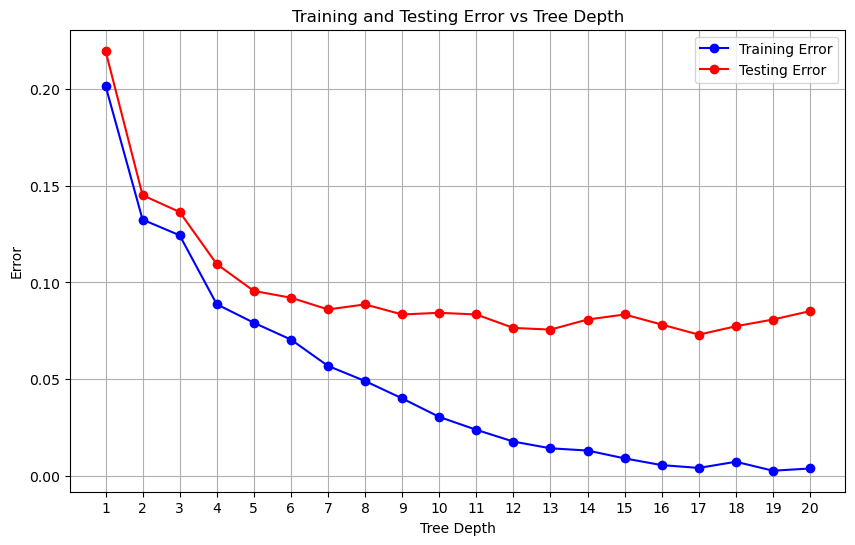

In [470]:
# 1.3: Plot training and testing error vs tree depth

plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, 'b-o', label='Training Error')
plt.plot(depths, test_errors, 'r-o', label='Testing Error')
plt.xlabel('Tree Depth')
plt.ylabel('Error')
plt.title('Training and Testing Error vs Tree Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

Observations:

Training Error: Decreases as depth increases, eventually reaching 0

Testing Error: Decreases initially as the tree learns useful patterns, reaches a minimum at the optimal depth, then increases

Recommendation: Based on this analysis, the optimal tree depth is 17, which gives the lowest testing error

In [471]:
# 2.1: Train Random Forest with T = 10, 50, 100, 500 trees
n_trees = [10, 50, 100, 500]
rf_results = []

for T in n_trees:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train)
    
    metrics = calculate_metrics(rf, X_train, X_test, y_train, y_test)
    metrics = {'T': T, **metrics}
    rf_results.append(metrics)

print("Random Forest Results:")
pd.DataFrame(rf_results)

Random Forest Results:


,T,Train Error,Train Accuracy,Train F1,Train AUC,Test Error,Test Accuracy,Test F1,Test AUC
0,10,0.0043,0.9957,0.9944,0.9999,0.0539,0.9461,0.9329,0.9818
1,50,0.0006,0.9994,0.9993,1.0000,0.0417,0.9583,0.9482,0.9884
2,100,0.0006,0.9994,0.9993,1.0000,0.0417,0.9583,0.9482,0.9879
3,500,0.0006,0.9994,0.9993,1.0000,0.0426,0.9574,0.9471,0.9876


Observations:
- As T increases, test accuracy and AUC generally improve or stabilize
- Training metrics remain very high (close to 100%) for all T values

In [472]:
# 2.2: Compare Random Forest (best T) with Decision Tree
print("COMPARISON: RANDOM FOREST vs DECISION TREE")

# Get best Random Forest results (T=100)
best_rf = rf_results[-2]  

comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test F1', 'Test AUC'],
    'Decision Tree (Entropy)': [
        metrics_entropy['Test Accuracy'],
        metrics_entropy['Test F1'],
        metrics_entropy['Test AUC']
    ],
    'Decision Tree (Gini)': [
        metrics_gini['Test Accuracy'],
        metrics_gini['Test F1'],
        metrics_gini['Test AUC']
    ],
    'Random Forest (T=100)': [
        best_rf['Test Accuracy'],
        best_rf['Test F1'],
        best_rf['Test AUC']
    ]
})
comparison_df


COMPARISON: RANDOM FOREST vs DECISION TREE


,Metric,Decision Tree (Entropy),Decision Tree (Gini),Random Forest (T=100)
0,Test Accuracy,0.9235,0.9149,0.9583
1,Test F1,0.9060,0.8977,0.9482
2,Test AUC,0.9189,0.9154,0.9879


Observations:
- Random Forest achieves higher test accuracy than single Decision Tree
- Random Forest has smaller gap between train and test metrics (less overfitting)
- Random Forest is more robust and stable

In [473]:
# 2.3: Compute and plot variable importance
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train, y_train)

importances = rf_best.feature_importances_
feature_indices = np.argsort(importances)[::-1]

print("Top 10 Most Important Features:")
for i in range(10):
    idx = feature_indices[i]
    print(f"  Feature {idx}: {importances[idx]:.4f}")

Top 10 Most Important Features:
  Feature 51: 0.1145
  Feature 52: 0.0984
  Feature 6: 0.0800
  Feature 15: 0.0721
  Feature 54: 0.0566
  Feature 55: 0.0564
  Feature 56: 0.0527
  Feature 20: 0.0471
  Feature 24: 0.0449
  Feature 18: 0.0301


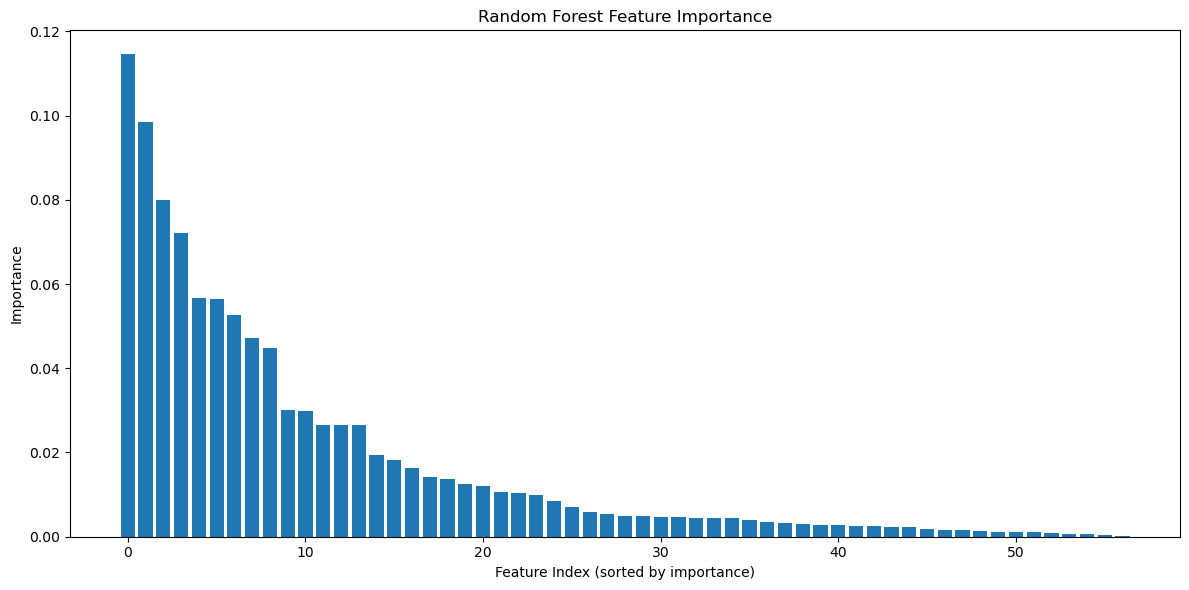

In [474]:
# Plot feature importance
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[feature_indices])
plt.xlabel('Feature Index (sorted by importance)')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

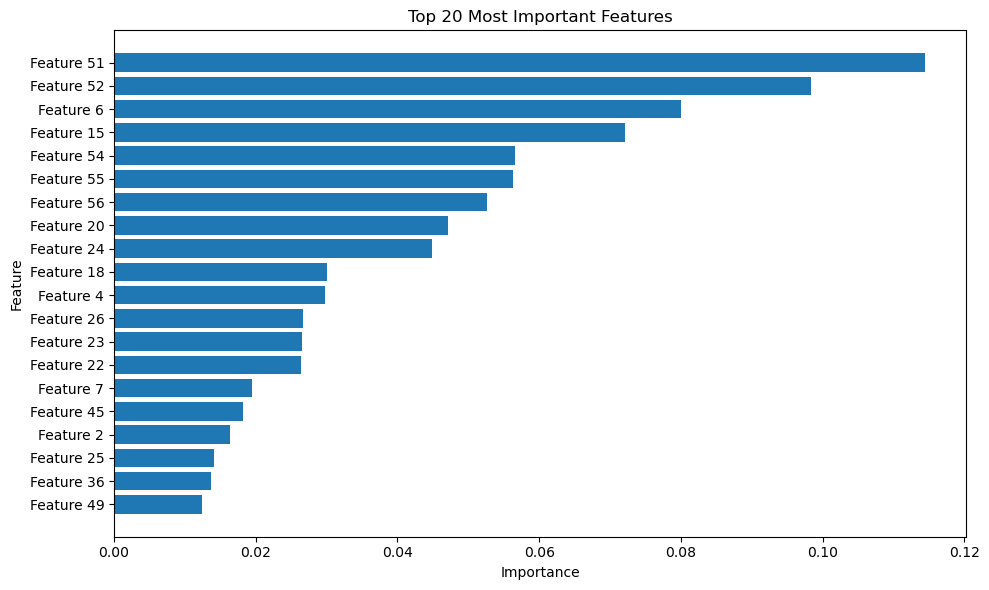

In [475]:
# Plot top 20 most important features
top_n = 20
top_indices = feature_indices[:top_n]
top_importances = importances[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_importances[::-1])
plt.yticks(range(top_n), [f'Feature {i}' for i in top_indices[::-1]])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Most Important Features')
plt.tight_layout()
plt.show()

In [476]:
# 3.1: Train AdaBoost with T = 10, 50, 100, 500 base classifiers
n_estimators = [10, 50, 100, 500]
ada_results = []

for T in n_estimators:
    base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
    ada = AdaBoostClassifier(estimator=base_tree, n_estimators=T, algorithm='SAMME', random_state=42)
    ada.fit(X_train, y_train)
    
    metrics = calculate_metrics(ada, X_train, X_test, y_train, y_test)
    metrics = {'T': T, **metrics}
    ada_results.append(metrics)

print("AdaBoost Results:")
pd.DataFrame(ada_results)

AdaBoost Results:


,T,Train Error,Train Accuracy,Train F1,Train AUC,Test Error,Test Accuracy,Test F1,Test AUC
0,10,0.0858,0.9142,0.8880,0.9643,0.0851,0.9149,0.8935,0.9663
1,50,0.0690,0.9310,0.9107,0.9789,0.0643,0.9357,0.9204,0.9800
2,100,0.0643,0.9357,0.9156,0.9821,0.0643,0.9357,0.9196,0.9819
3,500,0.0513,0.9487,0.9329,0.9898,0.0521,0.9479,0.9356,0.9854


OBSERVATIONS:
- As T increases, both training and testing metrics improve
- AdaBoost gradually reduces error
- Training accuracy increases steadily with more estimators

In [477]:
# 3.2: Compare AdaBoost vs Random Forest
print("COMPARISON: ADABOOST vs RANDOM FOREST")

comparison_data = []

for i, T in enumerate(n_estimators):
    comparison_data.append({
        'T': T,
        'Model': 'AdaBoost',
        'Test Accuracy': ada_results[i]['Test Accuracy'],
        'Test F1': ada_results[i]['Test F1'],
        'Test AUC': ada_results[i]['Test AUC']
    })
    comparison_data.append({
        'T': T,
        'Model': 'Random Forest',
        'Test Accuracy': rf_results[i]['Test Accuracy'],
        'Test F1': rf_results[i]['Test F1'],
        'Test AUC': rf_results[i]['Test AUC']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df

COMPARISON: ADABOOST vs RANDOM FOREST


,T,Model,Test Accuracy,Test F1,Test AUC
0,10,AdaBoost,0.9149,0.8935,0.9663
1,10,Random Forest,0.9461,0.9329,0.9818
2,50,AdaBoost,0.9357,0.9204,0.9800
3,50,Random Forest,0.9583,0.9482,0.9884
4,100,AdaBoost,0.9357,0.9196,0.9819
5,100,Random Forest,0.9583,0.9482,0.9879
6,500,AdaBoost,0.9479,0.9356,0.9854
7,500,Random Forest,0.9574,0.9471,0.9876


Observations:
- Random Forest generally achieves higher accuracy than AdaBoost
- AdaBoost improves more gradually as T increases
- Random Forest reaches good performance even with fewer trees

In [478]:
# 3.3: Prepare models for ROC curve comparison
# Decision Tree (from Problem 1)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
dt_prob = dt.predict_proba(X_test)[:, 1]

# Random Forest with 100 trees
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)
rf_prob = rf_100.predict_proba(X_test)[:, 1]

# AdaBoost with 100 estimators
base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_100 = AdaBoostClassifier(estimator=base_tree, n_estimators=100, algorithm='SAMME', random_state=42)
ada_100.fit(X_train, y_train)
ada_prob = ada_100.predict_proba(X_test)[:, 1]

In [479]:
# Calculate ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)
auc_ada = auc(fpr_ada, tpr_ada)

print(f"Decision Tree AUC: {auc_dt:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"AdaBoost AUC: {auc_ada:.4f}")

Decision Tree AUC: 0.9189
Random Forest AUC: 0.9879
AdaBoost AUC: 0.9819


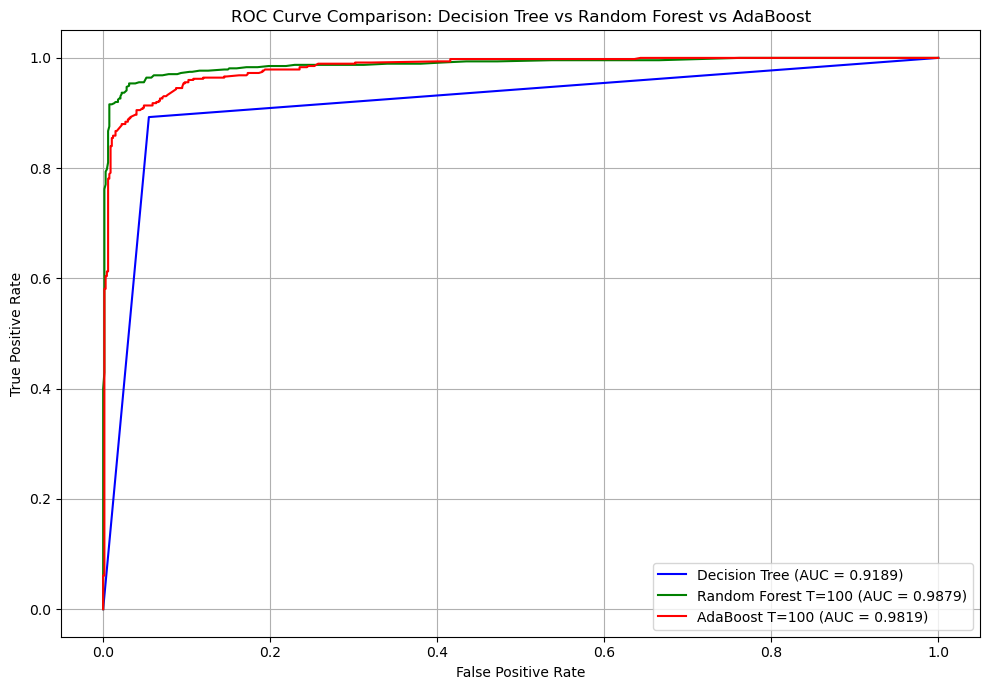

In [480]:
# 3.3: Plot ROC curves
plt.figure(figsize=(10, 7))

plt.plot(fpr_dt, tpr_dt, 'b-', label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, 'g-', label=f'Random Forest T=100 (AUC = {auc_rf:.4f})')
plt.plot(fpr_ada, tpr_ada, 'r-', label=f'AdaBoost T=100 (AUC = {auc_ada:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Decision Tree vs Random Forest vs AdaBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [481]:
# Load the Mushroom dataset
mushroom_df = pd.read_csv('./mushroom/agaricus-lepiota.data', header=None)

print("Dataset shape:", mushroom_df.shape)
print("\nFirst few rows:")
mushroom_df

Dataset shape: (8124, 23)

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [482]:
# First column = label (e=edible, p=poisonous)
y_mushroom = mushroom_df.iloc[:, 0]   
# Rest = features (22 categorical features) 
X_mushroom = mushroom_df.iloc[:, 1:]   

print("Features shape:", X_mushroom.shape)
print("Labels shape:", y_mushroom.shape)
print("\nClass distribution:")
y_mushroom.value_counts()

Features shape: (8124, 22)
Labels shape: (8124,)

Class distribution:


0
e    4208
p    3916
Name: count, dtype: int64

In [483]:
# Encode labels: e=0, p=1
le_label = LabelEncoder()
y_encoded = le_label.fit_transform(y_mushroom)
print("Label encoding:", dict(zip(le_label.classes_, range(len(le_label.classes_)))))

# Encode each feature column
X_encoded = X_mushroom.copy()
label_encoders = {}

for col in X_encoded.columns:
    X_encoded[col] = le_label.fit_transform(X_encoded[col])
    label_encoders[col] = le_label

X_encoded.head()

Label encoding: {'e': 0, 'p': 1}


,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,22
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


In [484]:
# Split: 75% training, 25% testing
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_encoded, y_encoded, test_size=0.25, random_state=42)

print("Training samples:", len(X_train_m))
print("Testing samples:", len(X_test_m))

Training samples: 6093
Testing samples: 2031


In [485]:
# 4.1 
X_train_arr = np.array(X_train_m)
y_train_arr = np.array(y_train_m)

# Count each class
n_total = len(y_train_arr)
n_edible = np.sum(y_train_arr == 0)
n_poisonous = np.sum(y_train_arr == 1)

# Calculate priors
prior_edible = n_edible / n_total
prior_poisonous = n_poisonous / n_total

print("PRIOR PROBABILITIES:")
print(f"  P(Edible) = {n_edible}/{n_total} = {prior_edible:.4f}")
print(f"  P(Poisonous) = {n_poisonous}/{n_total} = {prior_poisonous:.4f}")

PRIOR PROBABILITIES:
  P(Edible) = 3168/6093 = 0.5199
  P(Poisonous) = 2925/6093 = 0.4801


In [486]:
# Calculate Conditional Probabilities P(X_i = x | Y = class)
# With Laplace smoothing (alpha = 1)
alpha = 1  
n_features = X_train_arr.shape[1]

# Store conditional probabilities
# conditionals[class][feature][value] = probability
conditionals = {0: {}, 1: {}}

# Get samples for each class
# All edible samples
X_edible = X_train_arr[y_train_arr == 0]     
# All poisonous samples
X_poisonous = X_train_arr[y_train_arr == 1]   

# For each feature
for i in range(n_features):
    # Edible
    conditionals[0][i] = {}  
    # Poisonous
    conditionals[1][i] = {}  
    
    # Get all unique values for this feature
    all_values = np.unique(X_train_arr[:, i])
    n_values = len(all_values)
    
    # Calculate P(X_i = value | Edible) for each value
    for val in all_values:
        count_edible = np.sum(X_edible[:, i] == val)
        prob_edible = (count_edible + alpha) / (n_edible + alpha * n_values)
        conditionals[0][i][val] = prob_edible
        
        count_poisonous = np.sum(X_poisonous[:, i] == val)
        prob_poisonous = (count_poisonous + alpha) / (n_poisonous + alpha * n_values)
        conditionals[1][i][val] = prob_poisonous

print(f"\nExample Feature 0:")
print(f"  P(X0=0 | Edible) = {conditionals[0][0].get(0, 'N/A'):.4f}")
print(f"  P(X0=0 | Poisonous) = {conditionals[1][0].get(0, 'N/A'):.4f}")


Example Feature 0:
  P(X0=0 | Edible) = 0.0888
  P(X0=0 | Poisonous) = 0.0136


In [487]:
# 4.2: Function to predict class for test samples
def predict_naive_bayes(X_test, priors, conditionals):
    """
    Predict class for each sample in X_test
    Parameters: X_test : array
        Test samples (each row is a sample, each column is a feature)
    priors : dict
        Prior probabilities {0: P(Edible), 1: P(Poisonous)}
    conditionals : dict
        Conditional probabilities conditionals[class][feature][value]
    
    Returns:
    predictions : array
        Predicted class (0 or 1) for each sample
    probabilities : array
        Probability for each class for each sample
    """
    
    X_test_arr = np.array(X_test)
    n_samples = X_test_arr.shape[0]
    n_features = X_test_arr.shape[1]
    
    predictions = []
    probabilities = []
    
    # For each test sample
    for sample in X_test_arr:
        
        # Calculate log probability for each class
        log_prob_edible = np.log(priors[0])   
        log_prob_poisonous = np.log(priors[1])
        
        # Add log of each conditional probability
        for i in range(n_features):
            feature_value = sample[i]
            
            # P(X_i = value | Edible)
            if feature_value in conditionals[0][i]:
                log_prob_edible += np.log(conditionals[0][i][feature_value])
            
            # P(X_i = value | Poisonous)
            if feature_value in conditionals[1][i]:
                log_prob_poisonous += np.log(conditionals[1][i][feature_value])
        
        # Predict class with higher log probability
        if log_prob_edible > log_prob_poisonous:
            predictions.append(0)  # Edible
        else:
            predictions.append(1)  # Poisonous

        probabilities.append([log_prob_edible, log_prob_poisonous])
    
    return np.array(predictions), np.array(probabilities)

In [488]:
# Make predictions on test set
# Store priors in a dictionary
priors = {0: prior_edible, 1: prior_poisonous}

# Make predictions
y_pred_my, log_probs = predict_naive_bayes(X_test_m, priors, conditionals)

print(f"First 10 actual labels: {y_test_m[:10]}")
print(f"First 10 predictions:   {y_pred_my[:10]}")

# Count correct
correct = np.sum(y_pred_my == y_test_m)
print(f"Correct: {correct} / {len(y_test_m)}")

First 10 actual labels: [0 1 1 0 1 1 1 1 0 0]
First 10 predictions:   [0 1 1 0 1 1 1 1 0 0]
Correct: 1927 / 2031


In [489]:
# Example:
sample = np.array(X_test_m)[0]
print("First test sample features:", sample)
print()

# Calculate step by step
log_score_edible = np.log(priors[0])
log_score_poisonous = np.log(priors[1])

print(f" Start with priors:")
print(f" log(P(Edible)) = log({priors[0]:.4f}) = {log_score_edible:.4f}")
print(f" log(P(Poisonous)) = log({priors[1]:.4f}) = {log_score_poisonous:.4f}")
print()

# Add lo g of conditionals for each feature
for i in range(22):  
    val = sample[i]
    p_e = conditionals[0][i][val]
    p_p = conditionals[1][i][val]
    print(f" Feature {i}, value={val}:")
    print(f" P(X{i}={val}|Edible) = {p_e:.4f}, log = {np.log(p_e):.4f}")
    print(f" P(X{i}={val}|Poisonous) = {p_p:.4f}, log = {np.log(p_p):.4f}")

First test sample features: [2 0 4 0 5 1 1 0 3 1 3 2 0 7 7 0 2 1 0 3 3 1]

 Start with priors:
 log(P(Edible)) = log(0.5199) = -0.6540
 log(P(Poisonous)) = log(0.4801) = -0.7338

 Feature 0, value=2:
 P(X0=2|Edible) = 0.3774, log = -0.9743
 P(X0=2|Poisonous) = 0.3889, log = -0.9443
 Feature 1, value=0:
 P(X1=0|Edible) = 0.3698, log = -0.9948
 P(X1=0|Poisonous) = 0.1939, log = -1.6403
 Feature 2, value=4:
 P(X2=4|Edible) = 0.2967, log = -1.2149
 P(X2=4|Poisonous) = 0.2624, log = -1.3381
 Feature 3, value=0:
 P(X3=0|Edible) = 0.3426, log = -1.0712
 P(X3=0|Poisonous) = 0.8442, log = -0.1694
 Feature 4, value=5:
 P(X4=5|Edible) = 0.8130, log = -0.2070
 P(X4=5|Poisonous) = 0.0310, log = -3.4733
 Feature 5, value=1:
 P(X5=1|Edible) = 0.9552, log = -0.0458
 P(X5=1|Poisonous) = 0.9945, log = -0.0055
 Feature 6, value=1:
 P(X6=1|Edible) = 0.2830, log = -1.2624
 P(X6=1|Poisonous) = 0.0304, log = -3.4931
 Feature 7, value=0:
 P(X7=0|Edible) = 0.9356, log = -0.0665
 P(X7=0|Poisonous) = 0.4322, log

In [490]:
# 4.3: Calculate metrics for our Naive Bayes implementation
my_accuracy = accuracy_score(y_test_m, y_pred_my)
my_precision = precision_score(y_test_m, y_pred_my)
my_recall = recall_score(y_test_m, y_pred_my)
my_f1 = f1_score(y_test_m, y_pred_my)

print(f"Accuracy:  {my_accuracy:.4f}")
print(f"Precision: {my_precision:.4f}")
print(f"Recall:    {my_recall:.4f}")
print(f"F1 Score:  {my_f1:.4f}")

Accuracy:  0.9488
Precision: 0.9901
Recall:    0.9041
F1 Score:  0.9451


In [ ]:
# 4.4: Compare with sklearn's CategoricalNB
# # Create and train sklearn's Naive Bayes
sklearn_nb = CategoricalNB(alpha=1)  
sklearn_nb.fit(X_train_m, y_train_m)

# Make predictions
y_pred_sklearn = sklearn_nb.predict(X_test_m)

print(f"First 10 sklearn predictions: {y_pred_sklearn[:10]}")
print(f"First 10 my predictions:     {y_pred_my[:10]}")

Sklearn Naive Bayes trained!

First 10 sklearn predictions: [0 1 1 0 1 1 1 1 0 0]
First 10 our predictions:     [0 1 1 0 1 1 1 1 0 0]


In [492]:
# Calculate metrics for sklearn
sklearn_accuracy = accuracy_score(y_test_m, y_pred_sklearn)
sklearn_precision = precision_score(y_test_m, y_pred_sklearn)
sklearn_recall = recall_score(y_test_m, y_pred_sklearn)
sklearn_f1 = f1_score(y_test_m, y_pred_sklearn)

print("SKLEARN NAIVE BAYES (CategoricalNB):")
print("=" * 40)
print(f"Accuracy:  {sklearn_accuracy:.4f}")
print(f"Precision: {sklearn_precision:.4f}")
print(f"Recall:    {sklearn_recall:.4f}")
print(f"F1 Score:  {sklearn_f1:.4f}")

SKLEARN NAIVE BAYES (CategoricalNB):
Accuracy:  0.9488
Precision: 0.9901
Recall:    0.9041
F1 Score:  0.9451


Both implementations produce nearly identical results because they use the same Laplace smoothing (alpha=1) and the same mathematical formula